# Quick evaluation of simple models & simple vectorization techniques

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.models_eval import eval_pipeline_movies, eval_pipeline_presidents, build_experiments, eval_experiments

import gensim.downloader as api
from gensim.models.fasttext import load_facebook_model

init_notebook()

## Movies

In [35]:
from rital_nlp_project.movies.models_config import word2vec_model, fasttext_model, min_df, max_df

texts_movies, classes_movies = load_clean_data("../Dataset/clean/movies_clean.parquet")
# w2v_model = api.load(word2vec_model)
# ft_model = load_facebook_model(f"../models/{fasttext_model}")
# experiments = build_experiments("movies", models={"fasttext":ft_model, "word2vec":w2v_model})
# evals = eval_experiments(experiments, texts_movies, classes_movies, eval_pipeline_fn=eval_pipeline_movies, cv=False, split=True)
evals = pd.read_csv("evals/movies_evals.csv")


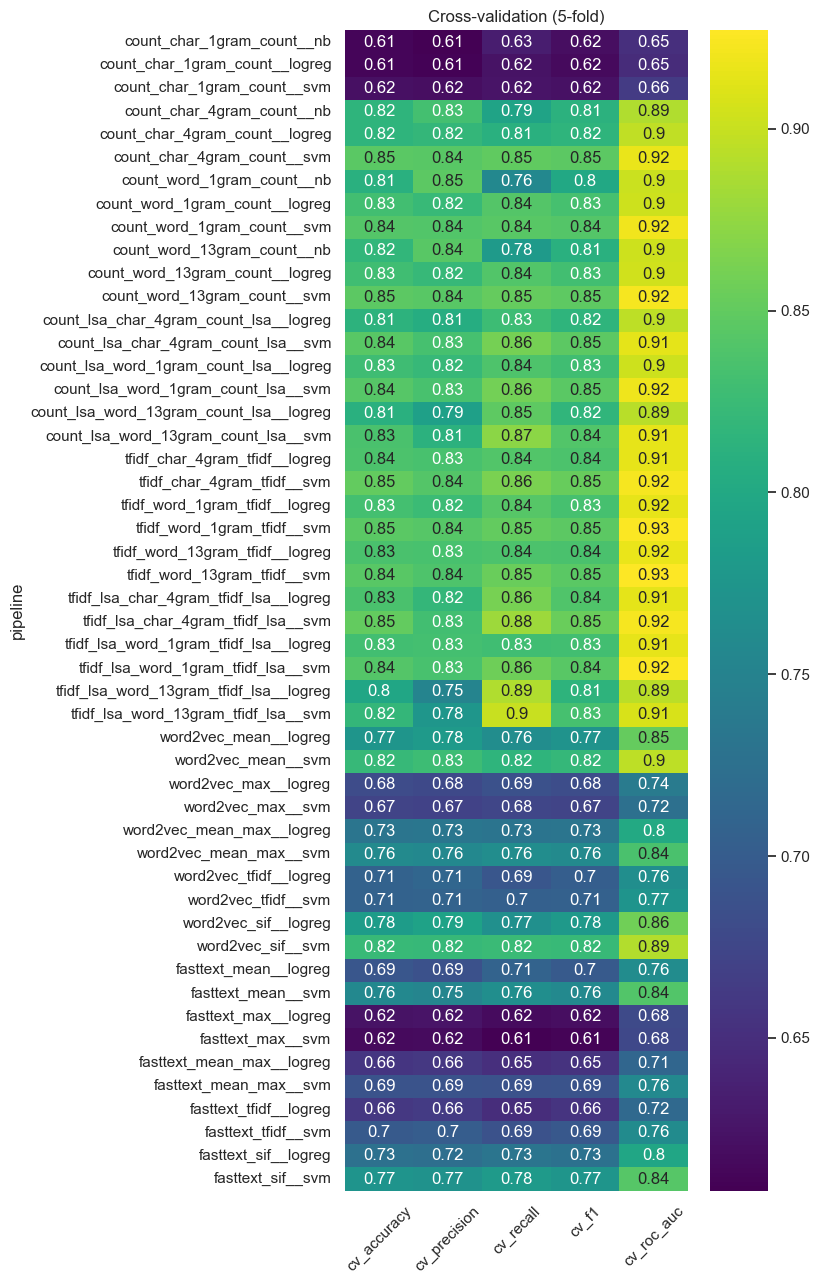

In [38]:
plt.figure(figsize=(8, 13))
cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Cross-validation (5-fold)")
plt.xticks(rotation=45)
plt.tight_layout()

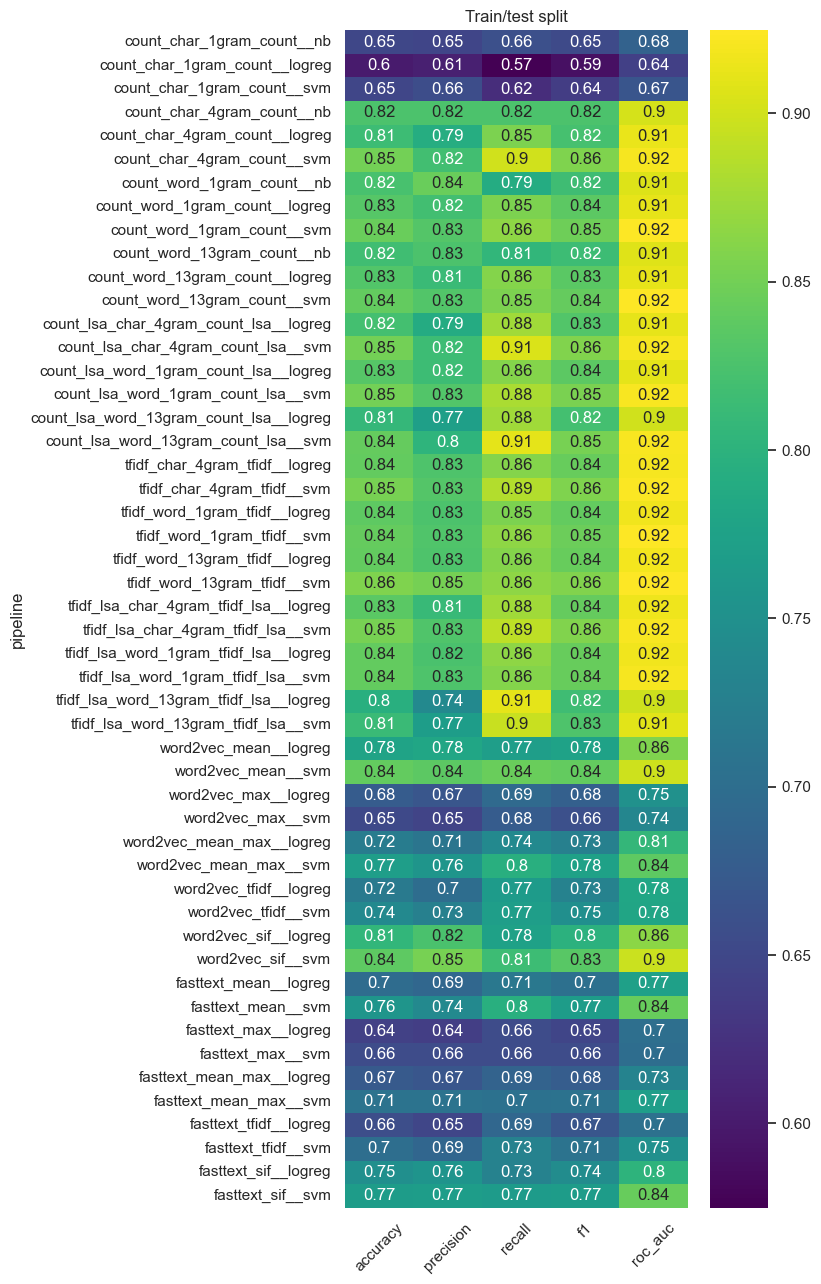

In [39]:
plt.figure(figsize=(8, 13))
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Train/test split")
plt.xticks(rotation=45)
plt.tight_layout()

In [16]:
# ROC AUC Curves

from sklearn.metrics import roc_curve
from rital_nlp_project.movies.models_utils import split_fn

experiments = build_experiments("movies", models=dict())
name, pipe = experiments[-10]["name"], experiments[-10]["pipeline"]
print("Baseline", name)

X_train, X_test, y_train, y_test = split_fn(texts_movies, classes_movies)
pipe.fit(X_train, y_train)
baseline_probs_1 = pipe.predict_proba(X_test)[:, 1]
bert_head_prob_1 =  pd.read_csv("../Dataset/predictions/movies_val_bert_head.csv")["prob_1"].values

Baseline tfidf_word_1gram_tfidf__logreg


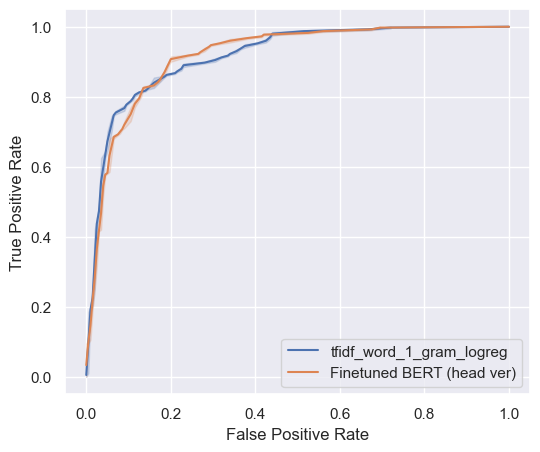

In [25]:
fig = plt.figure(figsize=(6, 5))
fpr, tpr, thresholds = roc_curve(y_test, baseline_probs_1)
sns.lineplot(x=fpr, y=tpr, label=f"tfidf_word_1_gram_logreg")

fpr, tpr, thresholds = roc_curve(y_test, bert_head_prob_1)
sns.lineplot(x=fpr, y=tpr, label=f"Finetuned BERT (head ver)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
fig.savefig("plots/movies_models/roc_curves.pdf", bbox_inches="tight")

## Presidents

In [47]:
from rital_nlp_project.presidents.models_config import fasttext_model

texts_pres, classes_pres = load_clean_data("../Dataset/clean/presidents_clean.parquet")

# ft_model = load_facebook_model(f"../models/{fasttext_model}")
# experiments = build_experiments("movies", models={"fasttext":ft_model})
# evals = eval_experiments(experiments, texts_pres, classes_pres, eval_pipeline_fn=eval_pipeline_movies, cv=False, split=True)
evals = pd.read_csv("evals/pres_evals.csv")

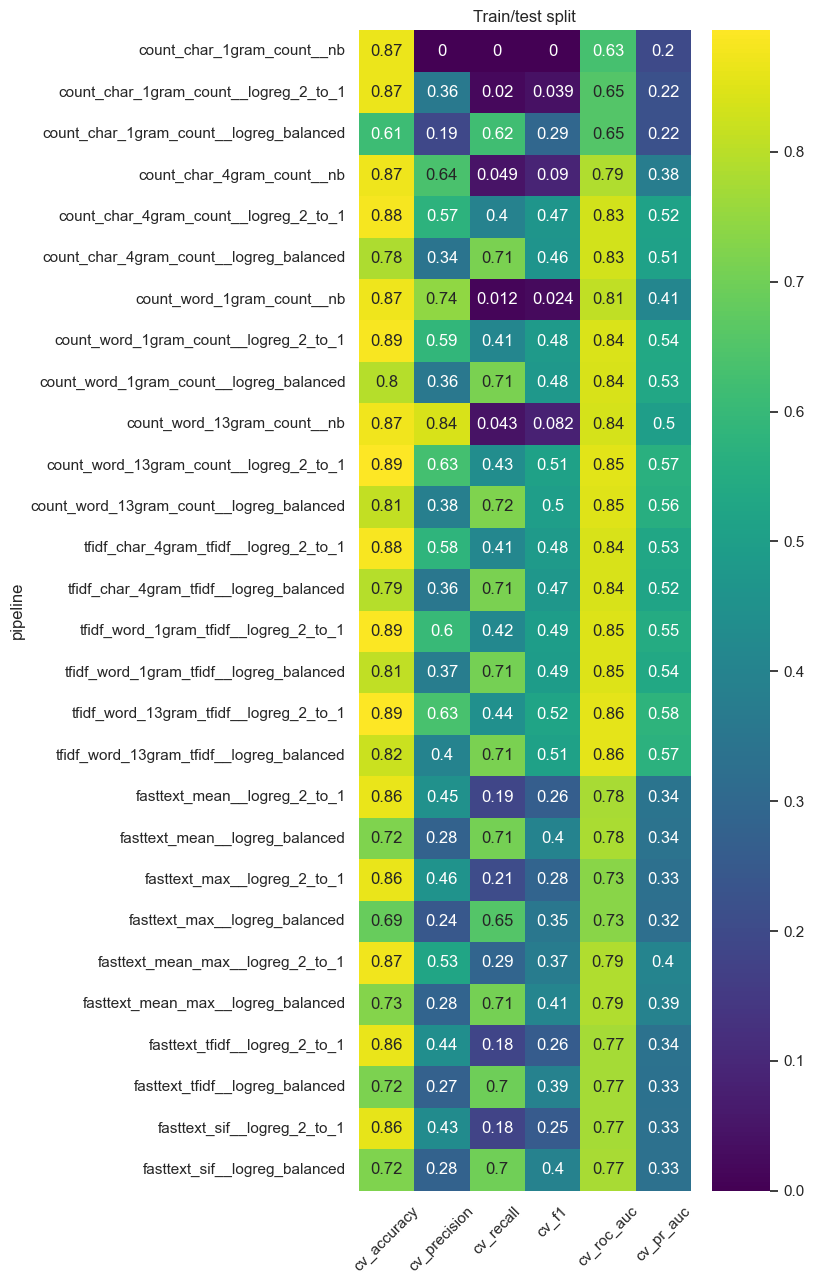

In [46]:
plt.figure(figsize=(8, 13))
cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc', 'cv_pr_auc']
sns.heatmap(evals.set_index("pipeline")[cols].dropna(), annot=True, cmap="viridis")
plt.title("Train/test split")
plt.xticks(rotation=45)
plt.tight_layout()

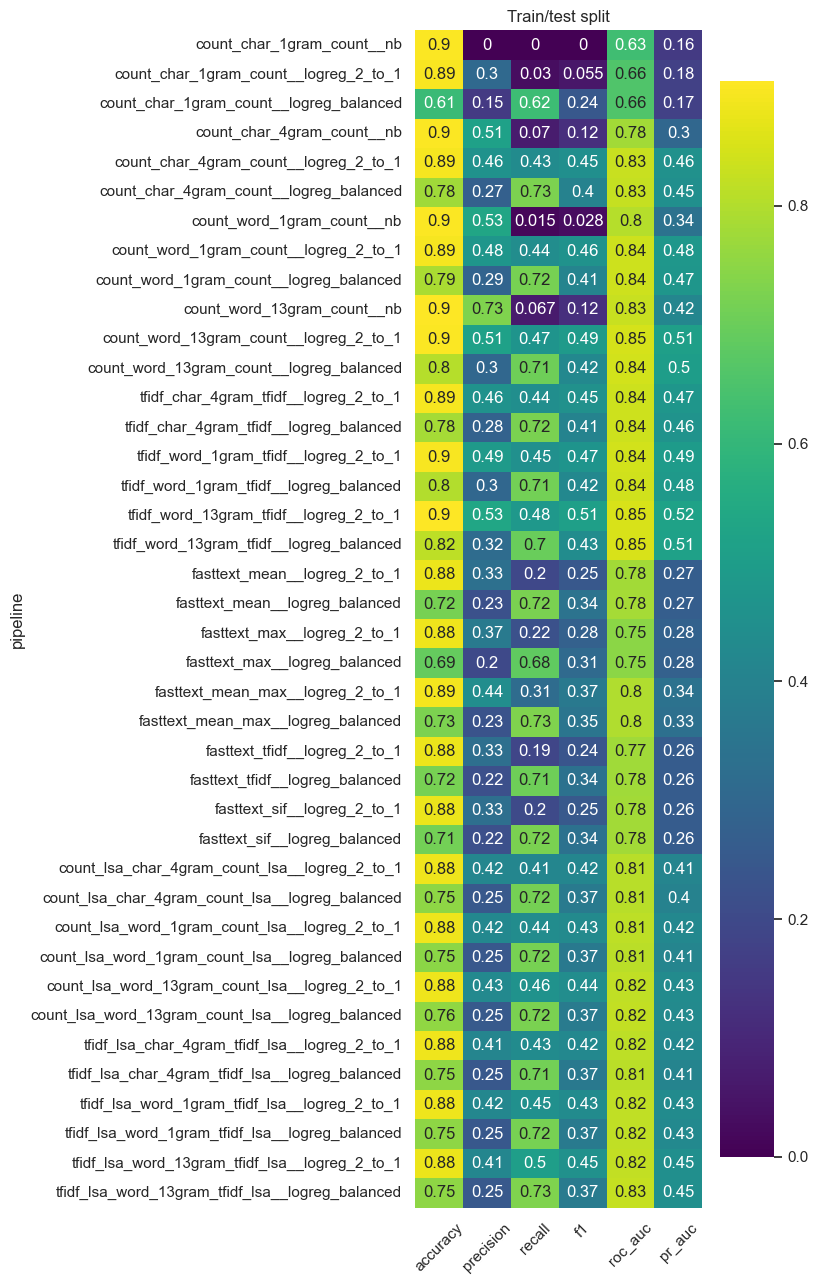

In [45]:
plt.figure(figsize=(8, 13))
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Train/test split")
plt.xticks(rotation=45)
plt.tight_layout()